# Pipeline de Masking Peri-lesional — BUS-BRA

## Equação Unificada
Toda condição de masking segue a mesma operação, variando apenas o mapa de pesos:

$$I' = W \cdot I + (1 - W) \cdot B$$

Onde:
- **I** = imagem original
- **M** = máscara binária da lesão (dilatada por raio `r`)
- **W** = mapa de pesos, construído a partir de M conforme o perfil de atenuação
- **B** = fundo substituto (preto ou blur da imagem original)

## Perfis de Atenuação
| Condição | W (dentro) | W (fora) | B (fundo) | O que remove |
|---|---|---|---|---|
| full | 1 | 1 | — | nada (baseline) |
| hard | 1 | 0 + feathering 2px | preto | tudo fora |
| scalar-0.5 | 1 | 0.5 | preto | contraste parcial |
| scalar-0.3 | 1 | 0.3 | preto | mais contraste |
| blur | 1 | 0 | imagem borrada | textura (alta freq.) |
| dist-EDT | 1 | decay(dist) | preto | info distante progressiva |

## Raios de Dilatação Morfológica
- `r ∈ {0, 10, 25}` px — margem além do nódulo mantida sem masking

In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import cv2
from scipy.ndimage import distance_transform_edt, binary_dilation
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

# ==============================================================================
# CONFIGURAÇÕES GLOBAIS
# ==============================================================================

# Caminhos do dataset BUSBRA
BASE_DIR = Path('.')  # raiz do projeto
BUSBRA_DIR = BASE_DIR / 'BUSBRA' / 'BUSBRA'
IMAGES_DIR = BUSBRA_DIR / 'Images'
MASKS_DIR = BUSBRA_DIR / 'Masks'
CSV_PATH = BUSBRA_DIR / 'bus_data.csv'
OUTPUT_DIR = BASE_DIR / 'processed'  # diretório de saída

# Parâmetros do pipeline
SIGMA_BLUR = 5          # σ do blur gaussiano (perfil blur)
SIGMA_EDT = 50          # σ da EDT — calibrado a partir da mediana do raio 
                        # equivalente dos nódulos (49.2 ≈ 50 px).
                        # Raio equiv. médio = 54.0 px, mediana = 49.2 px
                        # Calculado sobre todas as 1875 máscaras do BUSBRA.
FEATHERING_SIGMA = 2    # σ do feathering gaussiano na borda (armadilha #3)

# Raios de dilatação morfológica (px)
# r=0  → sem margem (masking começa exatamente na borda do nódulo)
# r=10 → ~20% do raio equiv. médio (margem conservadora)
# r=25 → ~50% do raio equiv. médio (margem ampla)
# NOTA: estes valores podem ser ajustados conforme análise visual dos nódulos.
RADII = [0, 10, 25]

# Perfis de atenuação (o 'full' não precisa de raio, é a baseline)
PROFILES = ['full', 'hard', 'scalar_05', 'scalar_03', 'blur', 'dist_edt']

# Lista de pesos escalares correspondentes a cada perfil escalar
# (hard = 0, scalar_05 = 0.5, scalar_03 = 0.3)
# Isso evidencia que hard masking é caso particular: atenuação escalar com c=0
SCALAR_WEIGHTS = {
    'hard': 0.0,
    'scalar_05': 0.5,
    'scalar_03': 0.3,
}

print(f"BUSBRA Images: {IMAGES_DIR}")
print(f"BUSBRA Masks:  {MASKS_DIR}")
print(f"Output:        {OUTPUT_DIR}")
print(f"σ blur:        {SIGMA_BLUR}")
print(f"σ EDT:         {SIGMA_EDT}")
print(f"Feathering σ:  {FEATHERING_SIGMA}")
print(f"Raios:         {RADII}")
print(f"Perfis:        {PROFILES}")

BUSBRA Images: BUSBRA/BUSBRA/Images
BUSBRA Masks:  BUSBRA/BUSBRA/Masks
Output:        processed
σ blur:        5
σ EDT:         50
Feathering σ:  2
Raios:         [0, 10, 25]
Perfis:        ['full', 'hard', 'scalar_05', 'scalar_03', 'blur', 'dist_edt']


In [2]:
# ==============================================================================
# CARREGAMENTO DO CSV E CATÁLOGO DE IMAGENS
# ==============================================================================

df = pd.read_csv(CSV_PATH)
print(f"Total de registros no CSV: {len(df)}")
print(f"Colunas: {list(df.columns)}")
print(f"\nDistribuição de patologia:")
print(df['Pathology'].value_counts())
print(f"\nFolds oficiais (K5B):")
print(df['K5B'].value_counts().sort_index())

# Verificar correspondência imagem ↔ máscara
image_files = sorted(os.listdir(IMAGES_DIR))
mask_files = sorted(os.listdir(MASKS_DIR))

print(f"\nImagens encontradas: {len(image_files)}")
print(f"Máscaras encontradas: {len(mask_files)}")

# Construir catálogo: ID → (path_imagem, path_mascara, patologia, fold)
catalog = {}
for _, row in df.iterrows():
    img_id = row['ID']
    img_path = IMAGES_DIR / f"{img_id}.png"
    mask_path = MASKS_DIR / f"mask_{img_id[4:]}.png"  # bus_XXXX -> mask_XXXX
    
    if img_path.exists() and mask_path.exists():
        catalog[img_id] = {
            'image_path': img_path,
            'mask_path': mask_path,
            'pathology': row['Pathology'],
            'fold': row['K5B'],
            'birads': row['BIRADS'],
        }

print(f"\nCatálogo construído: {len(catalog)} imagens com máscara correspondente")

Total de registros no CSV: 1875
Colunas: ['ID', 'Case', 'Histology', 'Pathology', 'BIRADS', 'Device', 'Width', 'Height', 'Side', 'HOB', 'K5B', 'K10B', 'HOP', 'K5P', 'K10P', 'BBOX']

Distribuição de patologia:
Pathology
benign       1268
malignant     607
Name: count, dtype: int64

Folds oficiais (K5B):
K5B
1    384
2    373
3    380
4    361
5    377
Name: count, dtype: int64

Imagens encontradas: 1875
Máscaras encontradas: 1875

Catálogo construído: 1875 imagens com máscara correspondente


In [3]:
# ==============================================================================
# FUNÇÕES AUXILIARES
# ==============================================================================

def load_image_and_mask(img_path, mask_path):
    """
    Carrega imagem (grayscale float64 [0,1]) e máscara (binária bool).
    
    Returns:
        image: np.ndarray float64 [0, 1], shape (H, W)
        mask:  np.ndarray bool, shape (H, W)
    """
    image = np.array(Image.open(img_path).convert('L')).astype(np.float64) / 255.0
    mask = np.array(Image.open(mask_path).convert('1')).astype(bool)
    
    assert image.shape == mask.shape, (
        f"Imagem e máscara com shapes diferentes: {image.shape} vs {mask.shape}"
    )
    return image, mask


def dilate_mask(mask, radius):
    """
    Dilatação morfológica da máscara usando kernel circular (disco).
    
    A dilatação define a margem além do nódulo que será mantida sem sofrer
    efeito de masking. Um raio de 0 significa nenhuma dilatação.
    
    Args:
        mask:   np.ndarray bool, shape (H, W)
        radius: int, raio da dilatação em pixels
        
    Returns:
        np.ndarray bool, shape (H, W) — máscara dilatada
    """
    if radius <= 0:
        return mask.copy()
    
    # Cria kernel circular (disco morfológico) — mais isotrópico que quadrado
    y, x = np.ogrid[-radius:radius+1, -radius:radius+1]
    structuring_element = (x**2 + y**2) <= radius**2
    
    return binary_dilation(mask, structure=structuring_element).astype(bool)


def apply_feathering(weight_map, mask, sigma=FEATHERING_SIGMA):
    """
    Aplica feathering gaussiano na borda da máscara para suavizar a transição
    entre região mascarada e não-mascarada.
    
    ARMADILHA #3: Um recorte binário perfeito desenha um contorno nítido com
    o formato exato da lesão. A rede poderia classificar lendo apenas esse
    contorno, sem olhar o conteúdo — isso seria um confundidor a favor do
    hard masking. O feathering de 1-2 px elimina esse artefato.
    
    O feathering é aplicado APENAS na região de transição (borda), não afeta
    o interior da lesão nem o fundo distante.
    
    Args:
        weight_map: np.ndarray float64 [0,1], shape (H, W) — mapa de pesos W
        mask:       np.ndarray bool — máscara (dilatada ou não)
        sigma:      float — σ do blur gaussiano para suavização da borda
        
    Returns:
        np.ndarray float64 [0,1] — mapa de pesos com borda suavizada
    """
    # Blur gaussiano no mapa de pesos inteiro
    smoothed = gaussian_filter(weight_map, sigma=sigma)
    
    # Manter o interior da lesão intacto (W=1 dentro) e o fundo distante
    # intacto (W=valor_perfil). Só a borda é afetada pelo feathering.
    # Identificar a região de borda: pixels próximos à fronteira da máscara
    # Usa EDT em ambas as direções para encontrar a banda de transição
    dist_inside = distance_transform_edt(mask)
    dist_outside = distance_transform_edt(~mask)
    
    # Banda de transição: dentro de ~3σ da borda (onde o feathering age)
    border_band = (dist_inside <= 3 * sigma) | (dist_outside <= 3 * sigma)
    
    # Na banda de transição, usar o valor suavizado; fora dela, manter original
    result = weight_map.copy()
    result[border_band] = smoothed[border_band]
    
    return result

In [5]:
# ==============================================================================
# EQUAÇÃO UNIFICADA E PERFIS DE ATENUAÇÃO
# ==============================================================================

def build_weight_map(mask_dilated, profile, image_original=None):
    """
    Constrói o mapa de pesos W e o fundo substituto B para um dado perfil.
    
    A equação unificada é:  I' = W · I + (1 - W) · B
    
    Cada perfil define como W e B são construídos a partir da máscara dilatada.
    
    IMPORTANTE — O hard masking é a atenuação escalar com c=0. Não são 
    experimentos separados — é um eixo contínuo, e o hard é a extremidade.
    Isso permite o gráfico AUC × intensidade de atenuação.
    
    Os três "soft" não são o mesmo efeito em doses diferentes:
    - Escalar: mexe no contraste (preserva estrutura espacial)
    - Blur: mata a textura (alta frequência)  
    - EDT: impõe um prior de proximidade (info distante é escurecida)
    
    Args:
        mask_dilated:    np.ndarray bool — máscara após dilatação
        profile:         str — nome do perfil
        image_original:  np.ndarray float64 [0,1] — imagem original (para blur)
        
    Returns:
        W: np.ndarray float64 [0,1], shape (H, W) — mapa de pesos
        B: np.ndarray float64 [0,1], shape (H, W) — fundo substituto
    """
    H, Wi = mask_dilated.shape
    
    if profile == 'full':
        # Baseline: nada muda. W=1 em tudo, B é irrelevante
        W = np.ones((H, Wi), dtype=np.float64)
        B = np.zeros((H, Wi), dtype=np.float64)
        return W, B
    
    if profile in SCALAR_WEIGHTS:
        # Perfis escalares: hard (c=0), scalar_05 (c=0.5), scalar_03 (c=0.3)
        c = SCALAR_WEIGHTS[profile]
        W = np.where(mask_dilated, 1.0, c)
        B = np.zeros((H, Wi), dtype=np.float64)  # fundo preto
        
        # Feathering na borda para TODOS os perfis escalares (armadilha #3)
        # No hard mask é especialmente crítico para evitar contorno perfeito,
        # mas nos soft escalares também suaviza a transição.
        W = apply_feathering(W, mask_dilated)
        return W, B
    
    if profile == 'blur':
        # ARMADILHA #2: O blur é calculado na imagem ORIGINAL, ANTES da
        # composição. Se borrarmos a imagem já mascarada, os pixels pretos
        # do fundo vazam para dentro da lesão e criam um halo escuro na
        # borda — um artefato que a rede vai aprender.
        assert image_original is not None, "Perfil 'blur' requer a imagem original"
        
        W = np.where(mask_dilated, 1.0, 0.0)
        W = apply_feathering(W, mask_dilated)
        
        # B = versão borrada da imagem ORIGINAL (antes de qualquer masking)
        B = gaussian_filter(image_original, sigma=SIGMA_BLUR)
        return W, B
    
    if profile == 'dist_edt':
        # Transformada de distância euclidiana: pixels mais distantes do
        # nódulo são progressivamente escurecidos.
        # W(fora) = exp(-dist / σ_EDT) — decay exponencial
        # σ_EDT = 50 px (mediana do raio equivalente dos nódulos BUSBRA)
        
        # EDT a partir da borda da máscara dilatada (distância de cada pixel
        # externo até o pixel mais próximo da máscara)
        dist = distance_transform_edt(~mask_dilated)
        
        # Decay exponencial: quanto mais longe, mais escuro
        W_outside = np.exp(-dist / SIGMA_EDT)
        
        # Dentro da máscara: W = 1.0 (sem atenuação)
        W = np.where(mask_dilated, 1.0, W_outside)
        
        # Feathering na borda para suavizar transição
        W = apply_feathering(W, mask_dilated)
        
        B = np.zeros((H, Wi), dtype=np.float64)  # fundo preto
        return W, B
    
    raise ValueError(f"Perfil desconhecido: {profile}")


def apply_masking(image, mask, profile, radius):
    """
    Aplica a equação unificada de masking:  I' = W · I + (1 - W) · B
    
    Pipeline (respeitando a ordem da Seção 6 do plano):
    1. Carregar I e M (já recebidos como argumentos)
    2. Dilatar M por raio r → M_dilated
    3. Construir W a partir de M_dilated (aplicar perfil de atenuação)
    4. Compor I' = W · I + (1 - W) · B
    
    NOTA: Augmentation geométrica (armadilha #1) e resize 224×224 
    serão aplicados no pipeline de TREINAMENTO, não aqui.
    Canvas permanece fixo (armadilha #4).
    
    Args:
        image:   np.ndarray float64 [0,1], shape (H, W)
        mask:    np.ndarray bool, shape (H, W) — máscara binária original
        profile: str — perfil de atenuação
        radius:  int — raio de dilatação em pixels
        
    Returns:
        np.ndarray float64 [0,1], shape (H, W) — imagem processada
    """
    # Full não depende de raio (baseline, imagem inalterada)
    if profile == 'full':
        return image.copy()
    
    # Passo 1: dilatar a máscara
    mask_dilated = dilate_mask(mask, radius)
    
    # Passo 2: construir W e B
    W, B = build_weight_map(mask_dilated, profile, image_original=image)
    
    # Passo 3: compor I' = W · I + (1 - W) · B
    result = W * image + (1.0 - W) * B
    
    # Garantir range [0, 1]
    result = np.clip(result, 0.0, 1.0)
    
    return result

print("Funções de masking definidas com sucesso.")
print(f"\nσ EDT = {SIGMA_EDT} px (mediana do raio equivalente dos nódulos BUSBRA)")
print(f"σ blur = {SIGMA_BLUR}")
print(f"Feathering σ = {FEATHERING_SIGMA} px")

Funções de masking definidas com sucesso.

σ EDT = 50 px (mediana do raio equivalente dos nódulos BUSBRA)
σ blur = 5
Feathering σ = 2 px


## ⚠️ Armadilhas Respeitadas (Seção 6 do Plano)

1. **Augmentation geométrica sincronizada** — NÃO é aplicada neste notebook. 
   Será aplicada no pipeline de treinamento com o **mesmo seed** para I e M.
   
2. **Blur na imagem original** — O `GaussianBlur` é calculado na imagem 
   original ANTES de qualquer composição/masking. Isso evita que pixels 
   pretos do fundo vazem para dentro da lesão criando halo escuro.

3. **Feathering de 2px na borda** — Aplicado em TODOS os perfis com 
   transição (hard, scalar, blur, EDT). Evita contorno binário perfeito 
   que a rede poderia usar como atalho classificatório (confundidor).

4. **Canvas fixo** — A imagem mantém suas dimensões originais. Não há 
   recorte nem redimensionamento diferenciado entre condições. O resize 
   para 224×224 será feito uniformemente no pipeline de treinamento.

In [6]:
# ==============================================================================
# PIPELINE DE PROCESSAMENTO EM LOTE
# ==============================================================================

def get_output_dir_name(profile, radius):
    """
    Retorna o nome do diretório de saída para uma combinação perfil × raio.
    
    O perfil 'full' não depende de raio, então não tem sufixo.
    Os demais perfis têm o formato: {profile}_r{radius}
    
    Exemplos: 'full', 'hard_r0', 'hard_r10', 'scalar_05_r25', 'blur_r0'
    """
    if profile == 'full':
        return 'full'
    return f"{profile}_r{radius}"


def save_processed_image(image_float, output_path):
    """
    Salva imagem float64 [0,1] como PNG uint8 [0,255] grayscale.
    """
    img_uint8 = (image_float * 255.0).clip(0, 255).astype(np.uint8)
    Image.fromarray(img_uint8, mode='L').save(output_path)


def process_all_images(catalog, profiles=PROFILES, radii=RADII, output_dir=OUTPUT_DIR):
    """
    Processa todas as imagens do catálogo para todas as combinações perfil × raio.
    
    A grade completa:
    - 6 perfis × 3 raios = 16 células úteis (full não tem raio)
    - Para cada célula: 1875 imagens processadas
    
    Args:
        catalog:    dict — catálogo de imagens {id: {image_path, mask_path, ...}}
        profiles:   list — perfis de atenuação a processar
        radii:      list — raios de dilatação a usar
        output_dir: Path — diretório base de saída
    """
    output_dir = Path(output_dir)
    
    # Gerar lista de todas as células (combinações perfil × raio)
    cells_to_process = []
    for profile in profiles:
        if profile == 'full':
            cells_to_process.append(('full', 0))  # raio irrelevante para full
        else:
            for radius in radii:
                cells_to_process.append((profile, radius))
    
    print(f"Células da grade a processar: {len(cells_to_process)}")
    for profile, radius in cells_to_process:
        print(f"  → {get_output_dir_name(profile, radius)}")
    
    # Criar diretórios de saída
    for profile, radius in cells_to_process:
        dir_name = get_output_dir_name(profile, radius)
        (output_dir / dir_name).mkdir(parents=True, exist_ok=True)
    
    # Processar cada imagem
    total_images = len(catalog)
    for img_id, info in tqdm(catalog.items(), desc="Processando imagens", total=total_images):
        # Carregar imagem e máscara UMA VEZ por imagem
        image, mask = load_image_and_mask(info['image_path'], info['mask_path'])
        
        # Aplicar cada célula da grade
        for profile, radius in cells_to_process:
            dir_name = get_output_dir_name(profile, radius)
            output_path = output_dir / dir_name / f"{img_id}.png"
            
            # Pular se já processado
            if output_path.exists():
                continue
            
            # Aplicar masking
            result = apply_masking(image, mask, profile, radius)
            
            # Salvar
            save_processed_image(result, output_path)
    
    print(f"\nProcessamento concluído!")
    print(f"Imagens salvas em: {output_dir}")

# NÃO executar automaticamente — validar visualmente primeiro
print("Pipeline de processamento em lote definido.")
print("Execute 'process_all_images(catalog)' após validação visual.")

Pipeline de processamento em lote definido.
Execute 'process_all_images(catalog)' após validação visual.


## Validação Visual

> "Antes de treinar qualquer coisa: salve um grid de exemplos de cada célula 
> da grade e olhe com os próprios olhos. Meia hora que evita duas semanas 
> perdidas." — Plano de Execução, Seção 6

A célula abaixo gera um grid completo mostrando:
- **Linhas**: 3 imagens de exemplo (escolhidas aleatoriamente)
- **Colunas**: todos os perfis de atenuação × raios

Verificar visualmente:
1. ✅ O blur NÃO cria halo escuro na borda da lesão
2. ✅ O feathering suaviza a transição (não há contorno binário perfeito)
3. ✅ O canvas permanece fixo em todas as condições (dimensões iguais)
4. ✅ A EDT escurece progressivamente conforme a distância
5. ✅ A região dentro do nódulo permanece inalterada em todos os perfis

VALIDAÇÃO VISUAL — PERFIS DE ATENUAÇÃO


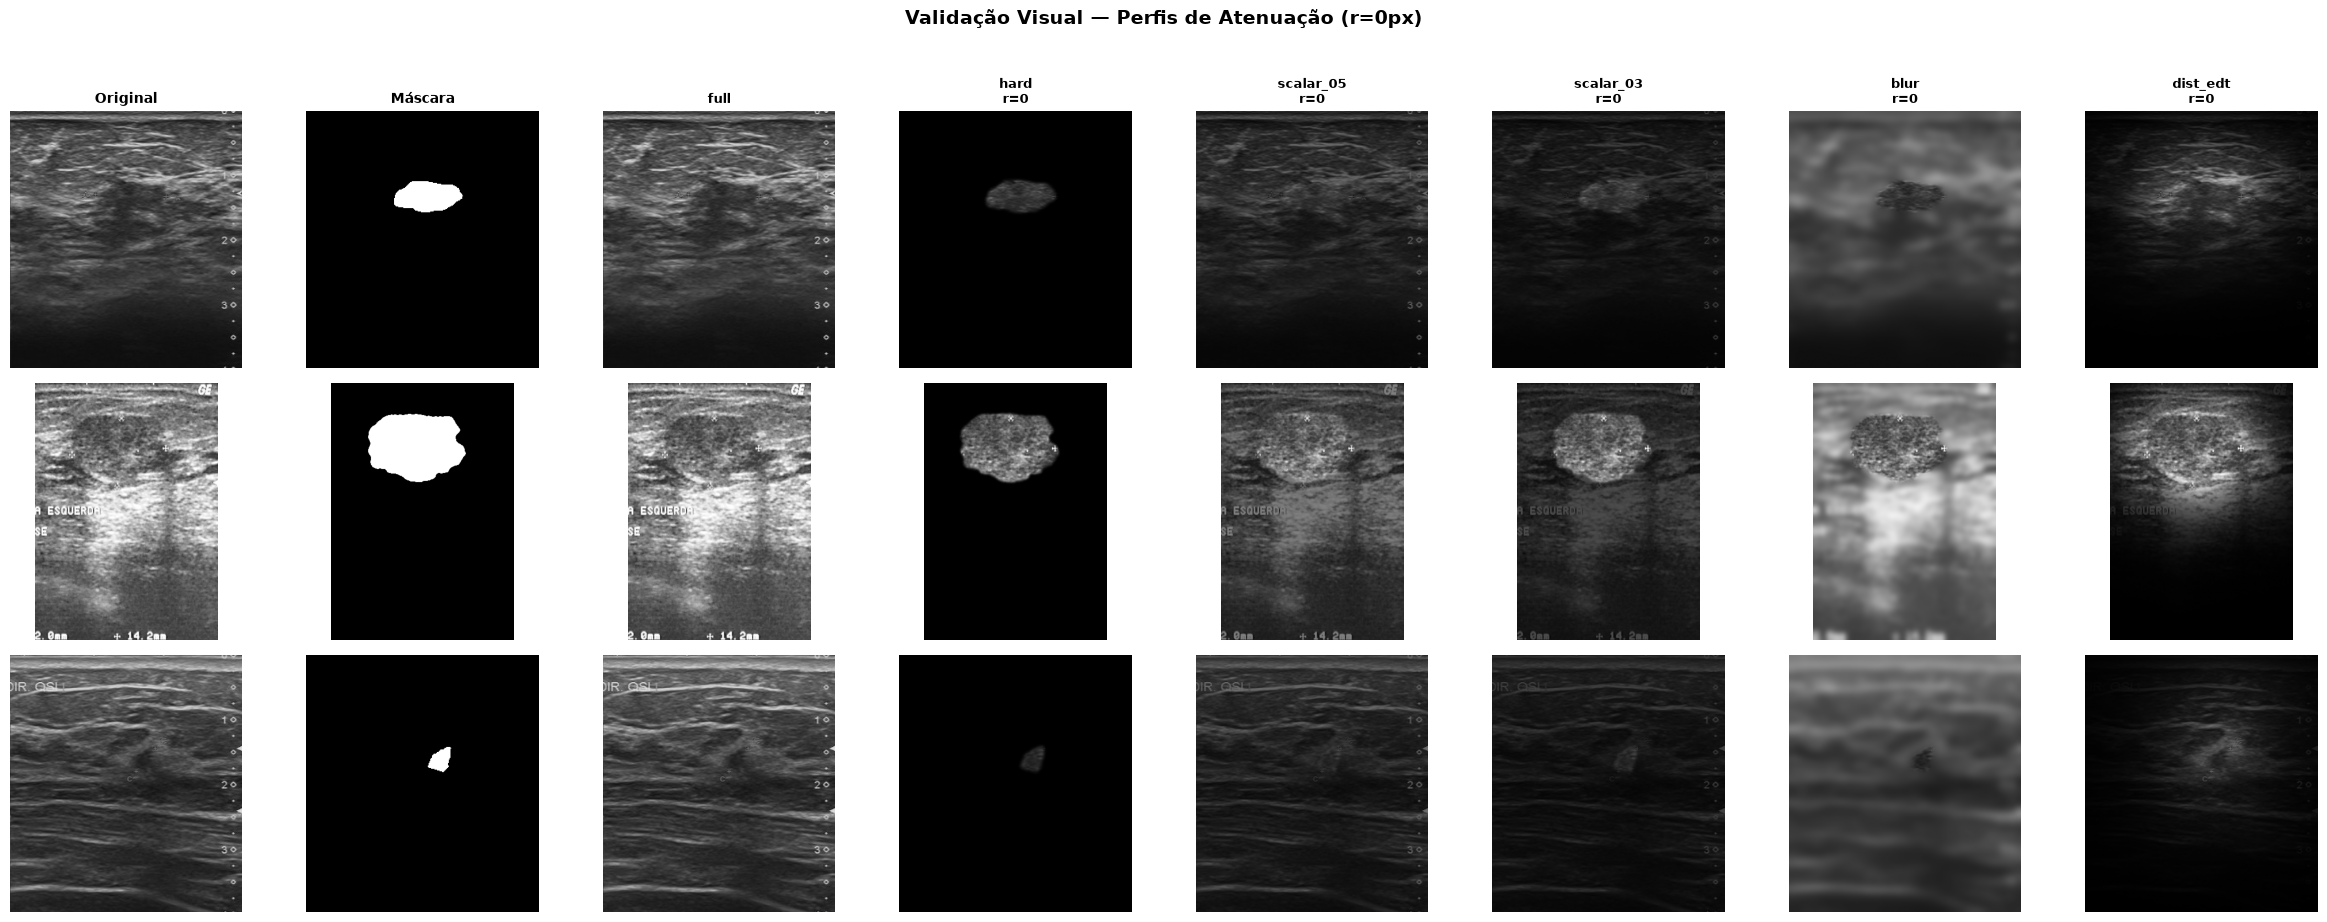

Grid salvo em: processed/grid_validation_r0.png

VALIDAÇÃO VISUAL — EFEITO DO RAIO DE DILATAÇÃO


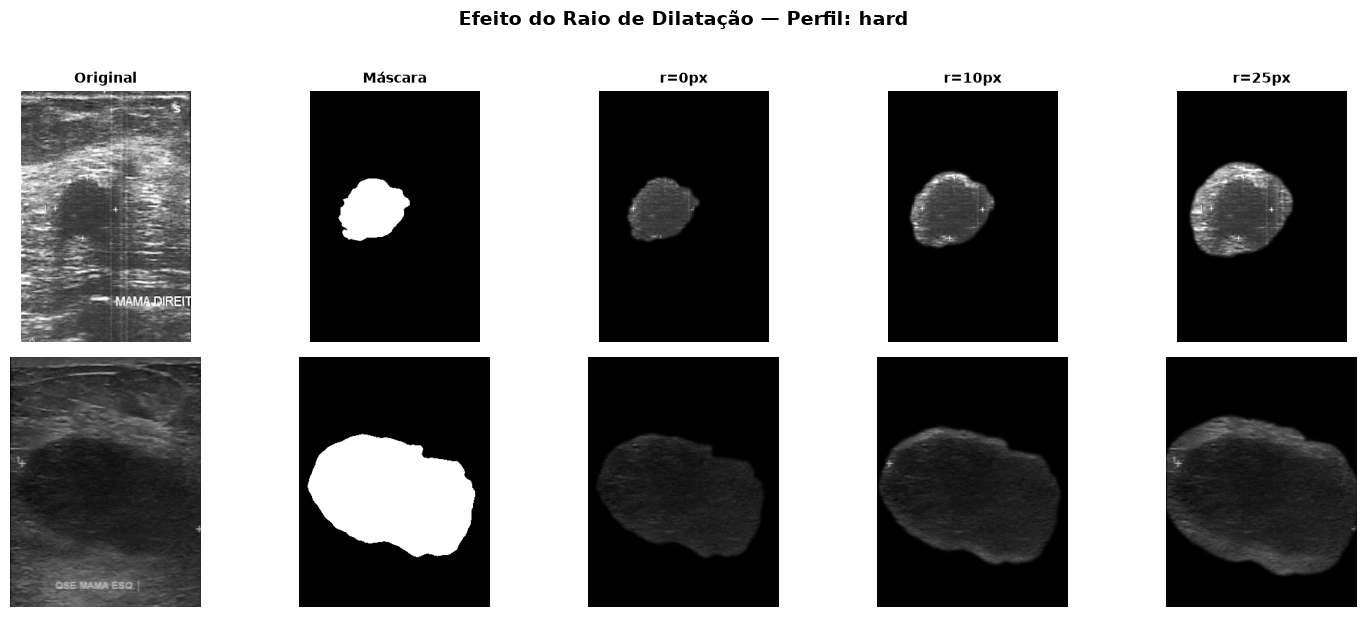

Grid salvo: processed/grid_radius_effect_hard.png


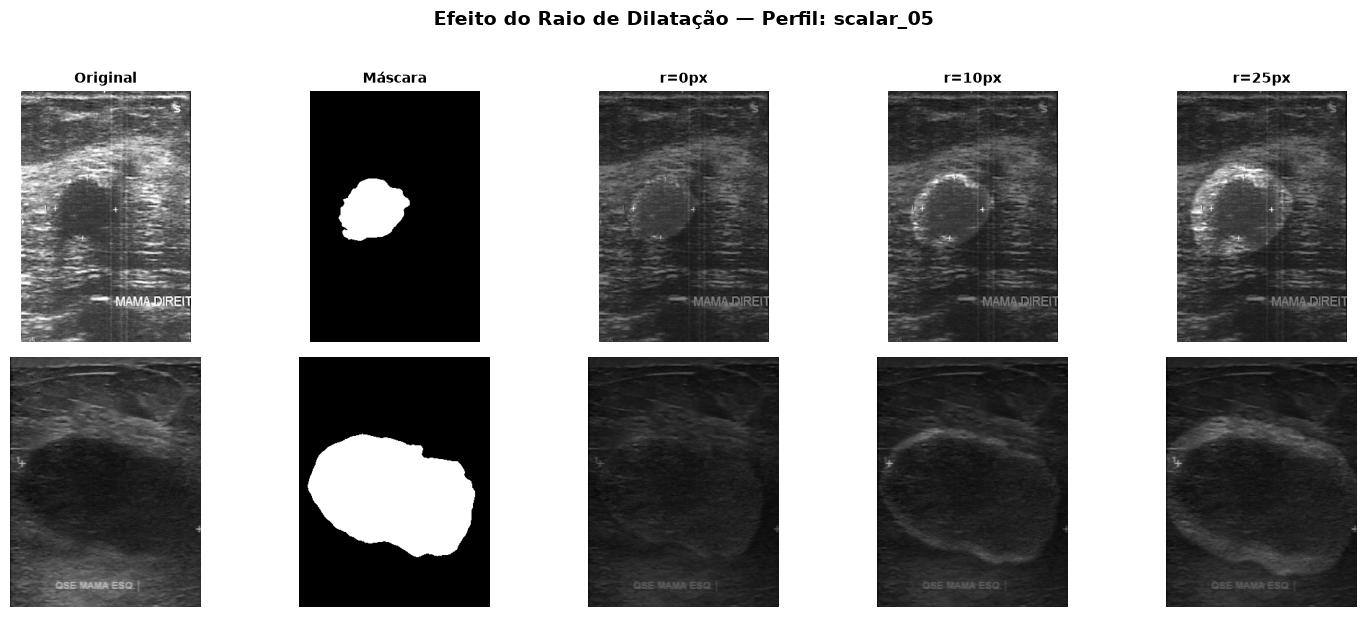

Grid salvo: processed/grid_radius_effect_scalar_05.png


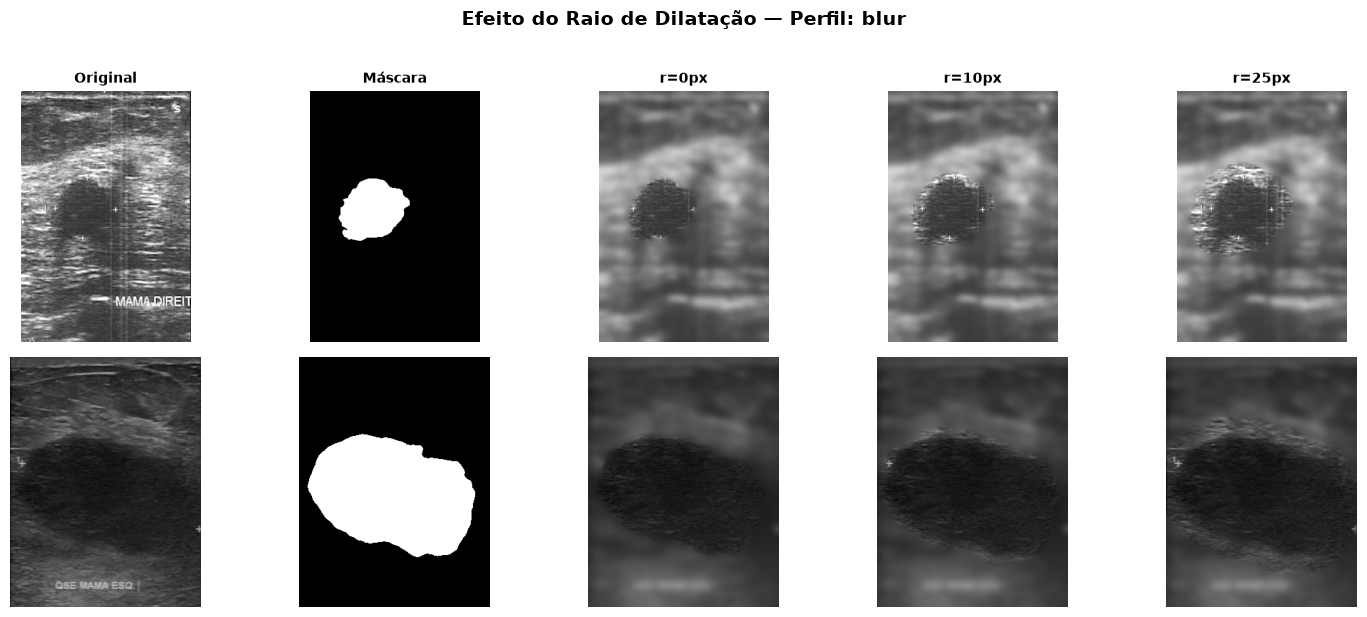

Grid salvo: processed/grid_radius_effect_blur.png


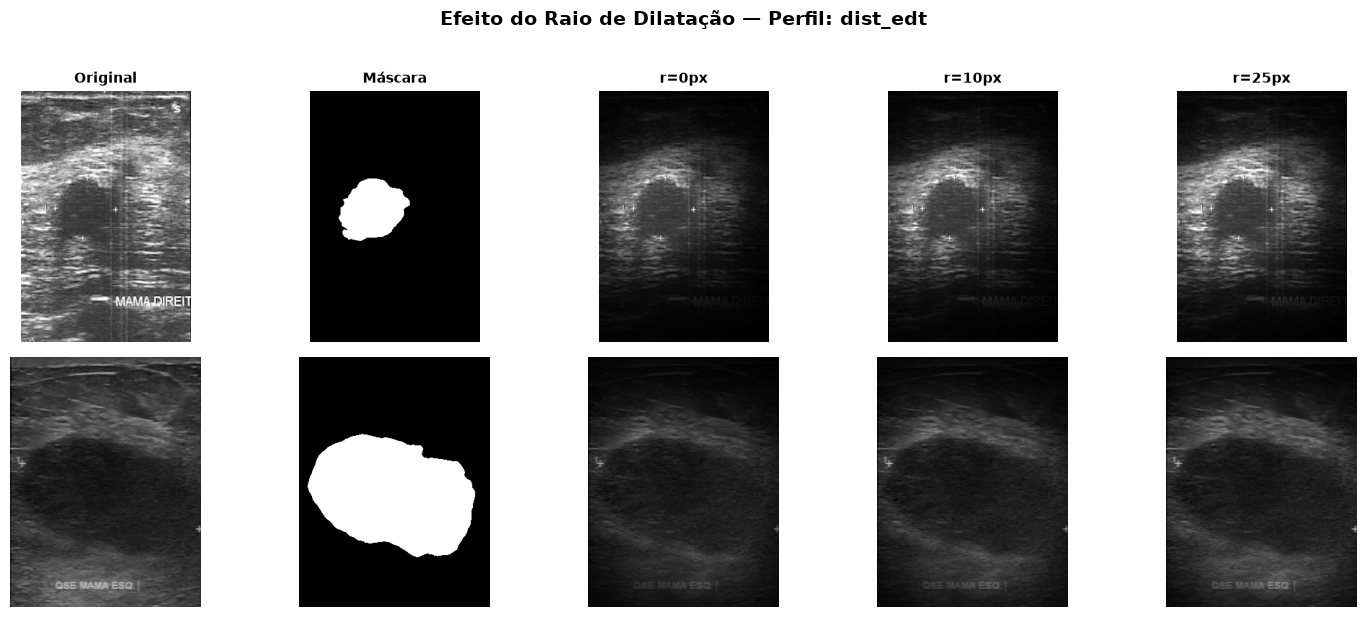

Grid salvo: processed/grid_radius_effect_dist_edt.png


In [7]:
# ==============================================================================
# VALIDAÇÃO VISUAL — GRID DE EXEMPLOS
# ==============================================================================

def visualize_masking_grid(catalog, n_examples=3, seed=42):
    """
    Gera um grid visual de exemplos para cada célula da grade.
    
    Linhas: imagens de exemplo
    Colunas: perfil × raio (todas as 16 células + original + máscara)
    
    Permite inspeção visual rápida para verificar:
    - Ausência de halos no blur
    - Feathering na borda
    - Canvas fixo
    - Decay progressivo na EDT
    """
    np.random.seed(seed)
    
    # Selecionar imagens de exemplo (variadas: benigno + maligno)
    ids = list(catalog.keys())
    # Escolher exemplos com mix de patologias
    benign_ids = [k for k, v in catalog.items() if v['pathology'] == 'benign']
    malign_ids = [k for k, v in catalog.items() if v['pathology'] == 'malignant']
    
    # Pegar exemplos de cada classe
    n_benign = min(n_examples // 2 + n_examples % 2, len(benign_ids))
    n_malign = min(n_examples - n_benign, len(malign_ids))
    
    example_ids = (
        list(np.random.choice(benign_ids, n_benign, replace=False)) +
        list(np.random.choice(malign_ids, n_malign, replace=False))
    )
    
    # Definir todas as combinações de perfil × raio para visualização
    # Agrupa: um raio por vez para facilitar comparação
    radius_to_show = RADII[0]  # Primeiro, mostrar tudo com r=0
    
    columns = ['original', 'mask']
    col_labels = ['Original', 'Máscara']
    
    for profile in PROFILES:
        if profile == 'full':
            columns.append(('full', 0))
            col_labels.append('full')
        else:
            columns.append((profile, radius_to_show))
            col_labels.append(f'{profile}\nr={radius_to_show}')
    
    n_rows = len(example_ids)
    n_cols = len(columns)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]
    
    for row_idx, img_id in enumerate(example_ids):
        info = catalog[img_id]
        image, mask = load_image_and_mask(info['image_path'], info['mask_path'])
        
        for col_idx, col in enumerate(columns):
            ax = axes[row_idx, col_idx]
            
            if col == 'original':
                ax.imshow(image, cmap='gray', vmin=0, vmax=1)
                if row_idx == 0:
                    ax.set_title('Original', fontsize=10, fontweight='bold')
                ax.set_ylabel(f"{img_id}\n({info['pathology']})", fontsize=8)
            elif col == 'mask':
                ax.imshow(mask, cmap='gray')
                if row_idx == 0:
                    ax.set_title('Máscara', fontsize=10, fontweight='bold')
            else:
                profile, radius = col
                result = apply_masking(image, mask, profile, radius)
                ax.imshow(result, cmap='gray', vmin=0, vmax=1)
                if row_idx == 0:
                    ax.set_title(col_labels[col_idx], fontsize=9, fontweight='bold')
            
            ax.axis('off')
    
    plt.suptitle(f'Validação Visual — Perfis de Atenuação (r={radius_to_show}px)', 
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'grid_validation_r0.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"Grid salvo em: {OUTPUT_DIR / 'grid_validation_r0.png'}")


def visualize_radius_effect(catalog, n_examples=2, seed=42):
    """
    Mostra o efeito dos diferentes raios de dilatação para um perfil fixo.
    
    Permite verificar visualmente como a margem cresce com cada raio,
    e se os valores {0, 10, 25} são adequados.
    """
    np.random.seed(seed)
    
    ids = list(catalog.keys())
    example_ids = list(np.random.choice(ids, n_examples, replace=False))
    
    # Perfis a mostrar para comparação de raios
    profiles_to_show = ['hard', 'scalar_05', 'blur', 'dist_edt']
    
    for profile in profiles_to_show:
        n_rows = len(example_ids)
        n_cols = len(RADII) + 2  # +2 para original e máscara
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 3 * n_rows))
        if n_rows == 1:
            axes = axes[np.newaxis, :]
        
        for row_idx, img_id in enumerate(example_ids):
            info = catalog[img_id]
            image, mask = load_image_and_mask(info['image_path'], info['mask_path'])
            
            # Original
            axes[row_idx, 0].imshow(image, cmap='gray', vmin=0, vmax=1)
            axes[row_idx, 0].set_ylabel(f"{img_id}\n({info['pathology']})", fontsize=8)
            if row_idx == 0:
                axes[row_idx, 0].set_title('Original', fontsize=10, fontweight='bold')
            axes[row_idx, 0].axis('off')
            
            # Máscara
            axes[row_idx, 1].imshow(mask, cmap='gray')
            if row_idx == 0:
                axes[row_idx, 1].set_title('Máscara', fontsize=10, fontweight='bold')
            axes[row_idx, 1].axis('off')
            
            # Cada raio
            for r_idx, radius in enumerate(RADII):
                result = apply_masking(image, mask, profile, radius)
                axes[row_idx, r_idx + 2].imshow(result, cmap='gray', vmin=0, vmax=1)
                if row_idx == 0:
                    axes[row_idx, r_idx + 2].set_title(f'r={radius}px', fontsize=10, fontweight='bold')
                axes[row_idx, r_idx + 2].axis('off')
        
        plt.suptitle(f'Efeito do Raio de Dilatação — Perfil: {profile}', 
                     fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f'grid_radius_effect_{profile}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Grid salvo: {OUTPUT_DIR / f'grid_radius_effect_{profile}.png'}")


# Criar diretório de saída para as validações
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Gerar grids de validação
print("=" * 60)
print("VALIDAÇÃO VISUAL — PERFIS DE ATENUAÇÃO")
print("=" * 60)
visualize_masking_grid(catalog, n_examples=3)

print("\n" + "=" * 60)
print("VALIDAÇÃO VISUAL — EFEITO DO RAIO DE DILATAÇÃO")
print("=" * 60)
visualize_radius_effect(catalog, n_examples=2)

## Detalhes Técnicos — σ EDT e Raios de Margem

### Cálculo do σ EDT
O σ da transformada de distância euclidiana foi calibrado com base no 
**raio equivalente** dos nódulos do BUSBRA (raio de um círculo com mesma 
área que a lesão):

| Estatística | Valor (px) |
|---|---|
| Média | 54.0 |
| **Mediana** | **49.2 ≈ 50** |
| Desvio padrão | 24.5 |
| P10 | 27.0 |
| P25 | 35.4 |
| P75 | 68.2 |
| P90 | 87.3 |

**σ_EDT = 50 px** (arredondamento da mediana). Isso significa que, na 
distância de 50 px da borda do nódulo, a intensidade cai para ~37% (1/e). 
Na distância de 100 px (~2σ), cai para ~14%. Na distância de 150 px (~3σ), 
cai para ~5%.

### Raios de Margem
Com nódulos de raio mediano ~50 px:
- **r=0**: sem margem (masking na borda exata do nódulo)
- **r=10**: ~20% do raio médio — margem conservadora
- **r=25**: ~50% do raio médio — margem ampla

**Sugestão adicional** (pós-análise): considerar r=15 (~30% do raio médio) 
como intermediário, se a grade de 3 raios não capturar bem a transição.

In [8]:
# ==============================================================================
# PROCESSAMENTO EM LOTE — Descomentar e executar após validação visual
# ==============================================================================

# ATENÇÃO: Este bloco processa TODAS as 1875 imagens para TODAS as 16 células
# da grade. Isso pode levar alguns minutos.
#
# Só executar APÓS confirmar visualmente que os grids estão corretos!

process_all_images(catalog)

Células da grade a processar: 16
  → full
  → hard_r0
  → hard_r10
  → hard_r25
  → scalar_05_r0
  → scalar_05_r10
  → scalar_05_r25
  → scalar_03_r0
  → scalar_03_r10
  → scalar_03_r25
  → blur_r0
  → blur_r10
  → blur_r25
  → dist_edt_r0
  → dist_edt_r10
  → dist_edt_r25


Processando imagens: 100%|██████████| 1875/1875 [1:27:14<00:00,  2.79s/it]


Processamento concluído!
Imagens salvas em: processed
